# 📊 Exploratory Data Analysis (EDA) - Persiapan Lengkap

Notebook ini melakukan **Exploratory Data Analysis (EDA) lengkap** untuk memahami dataset siswa:
- **EDA Univariate**: Analisis distribusi setiap variabel
- **EDA Multivariate**: Analisis hubungan antar variabel
- **EDA Numerikal**: Statistik dan korelasi
- **EDA Kategorikal**: Distribusi kategori dan asosiasi

Hasil EDA akan membantu mengidentifikasi **faktor-faktor yang mempengaruhi dropout**.

# 📊 Proyek Akhir: Prediksi Status Siswa - Perusahaan Edutech

**Membuat sistem machine learning untuk memprediksi status siswa (Dropout/Enrolled/Graduate) dan mengidentifikasi faktor-faktor yang mempengaruhi dropout**

- Nama:SHAH FIRIZKI AZMI
- Email:Ipengi794@gmail.com
- Id Dicoding:shah-firizki-azmi

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# ============================================================================
# SELURUH LIBRARY IMPORTS - SECTION 1: SETUP ENVIRONMENT
# ============================================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization & Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Model Training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Model Persistence & Serialization
import joblib

# Utility
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil di-import!")
print("=" * 70)

✅ Semua library berhasil di-import!


## Section 2: Memuat dan Memahami Dataset
Langkah pertama adalah **memuat dataset** dari berbagai sumber (lokal atau GitHub) dan melakukan **initial understanding**

In [3]:
# ============================================================================
# SECTION 2: LOAD DATA, EXPLORATION, DAN UNDERSTANDING
# VARIABEL YANG DIDEFINISIKAN: df, missing_count, status_counts, status_pct
# ============================================================================

print("\n📊 SECTION 2: MEMUAT DAN MEMAHAMI DATASET")
print("=" * 70)

import os
import urllib.request

# Coba berbagai path possibilities
possible_paths = [
    '../../Dataset/data.csv',
    '../Dataset/data.csv',
    'Dataset/data.csv',
    os.path.join('..', '..', 'Dataset', 'data.csv')
]

df = None  # ✅ DEFINE: df variable

# Coba load dari local path
for path in possible_paths:
    try:
        if os.path.exists(path):
            df = pd.read_csv(path, sep=';')
            print(f"✅ Dataset berhasil dimuat dari: {path}")
            break
    except Exception as e:
        continue

# Jika local path tidak ada, download dari GitHub
if df is None:
    print("📥 Mengunduh dataset dari GitHub...")
    try:
        url = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"
        df = pd.read_csv(url, sep=';')
        print(f"✅ Dataset berhasil diunduh dari GitHub!")
    except Exception as e:
        raise FileNotFoundError(f"Tidak dapat memuat dataset: {e}")

print(f"\n✅ Dataset berhasil dimuat!")
print(f"\n📌 DIMENSI DATASET:")
print(f"   • Total Baris (Records): {df.shape[0]:,}")
print(f"   • Total Kolom (Features): {df.shape[1]}")
print(f"   • Memory Usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

print(f"\n📌 INFORMASI DATASET:")
print(f"   • First Column: {df.columns[0]}")
print(f"   • Last Column: {df.columns[-1]}")

print(f"\n📌 MISSING VALUES:")
missing_count = df.isnull().sum().sum()  # ✅ DEFINE: missing_count
print(f"   • Total Missing Values: {missing_count}")

print(f"\n📌 TARGET VARIABLE (Status) - DISTRIBUSI AWAL:")
status_counts = df['Status'].value_counts()  # ✅ DEFINE: status_counts
status_pct = df['Status'].value_counts(normalize=True) * 100  # ✅ DEFINE: status_pct
for status in status_counts.index:
    print(f"   • {status}: {status_counts[status]:,} records ({status_pct[status]:.1f}%)")

print(f"\n✅ Data Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n✅ Dataset Understanding Complete!")


📊 SECTION 2: MEMUAT DAN MEMAHAMI DATASET
📥 Mengunduh dataset dari GitHub...
✅ Dataset berhasil diunduh dari GitHub!

✅ Dataset berhasil dimuat!

📌 DIMENSI DATASET:
   • Total Baris (Records): 4,424
   • Total Kolom (Features): 37
   • Memory Usage: 1.49 MB

📌 INFORMASI DATASET:
   • First Column: Marital_status
   • Last Column: Status

📌 MISSING VALUES:
   • Total Missing Values: 0

📌 TARGET VARIABLE (Status) - DISTRIBUSI AWAL:
   • Graduate: 2,209 records (49.9%)
   • Dropout: 1,421 records (32.1%)
   • Enrolled: 794 records (17.9%)

✅ Data Shape: 4424 rows × 37 columns

✅ Dataset Understanding Complete!


## Section 3: Exploratory Data Analysis (EDA) Univariate
**Analisis distribusi setiap variabel secara individual** - Mengidentifikasi pola, outliers, dan karakteristik setiap fitur

📊 EDA UNIVARIATE: VARIABEL NUMERIK

Variabel Numerik (36): ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', '

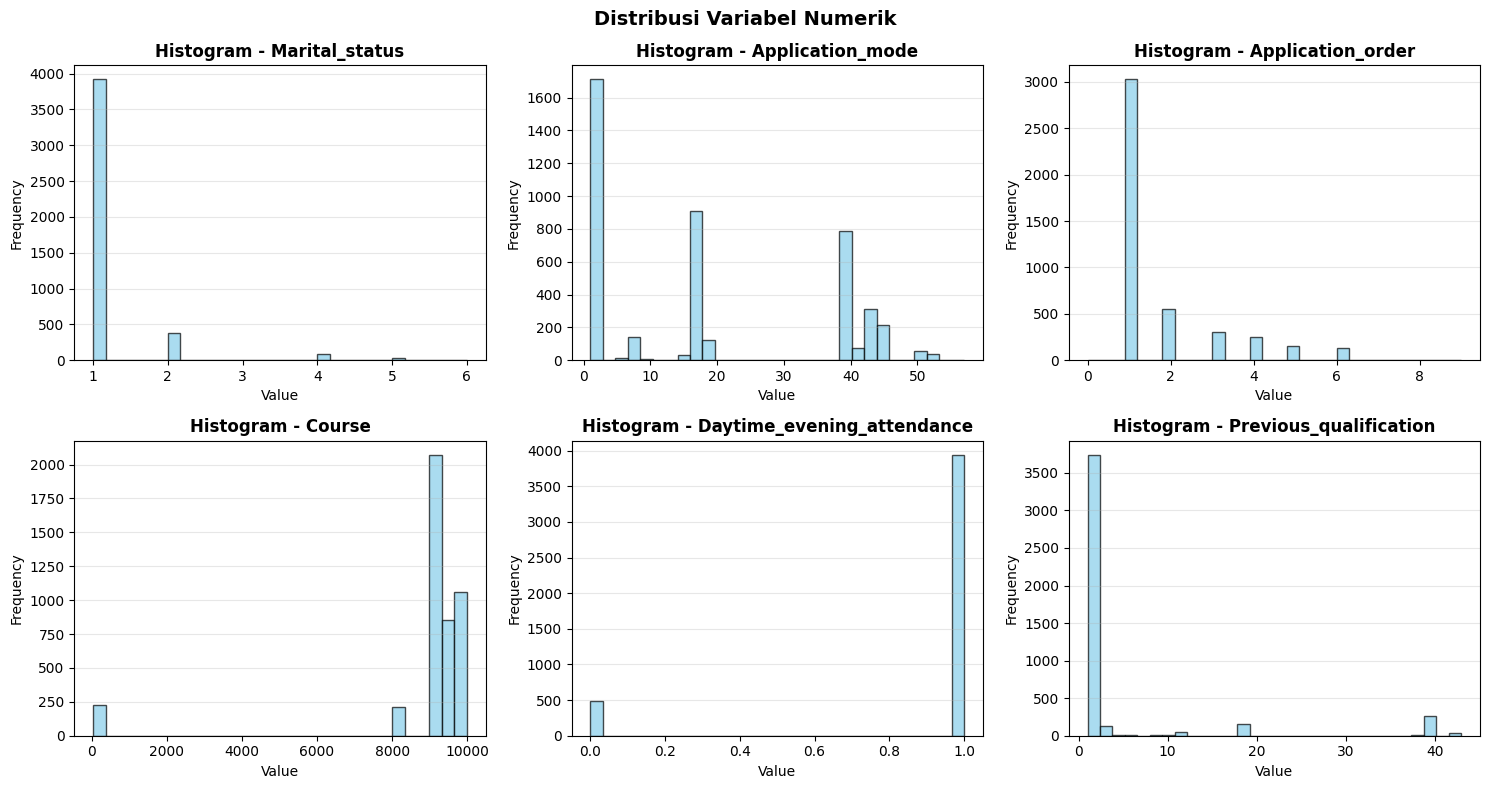


📊 EDA UNIVARIATE: VARIABEL KATEGORIKAL

Variabel Kategorikal (1): ['Status']


Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Unique values: 3


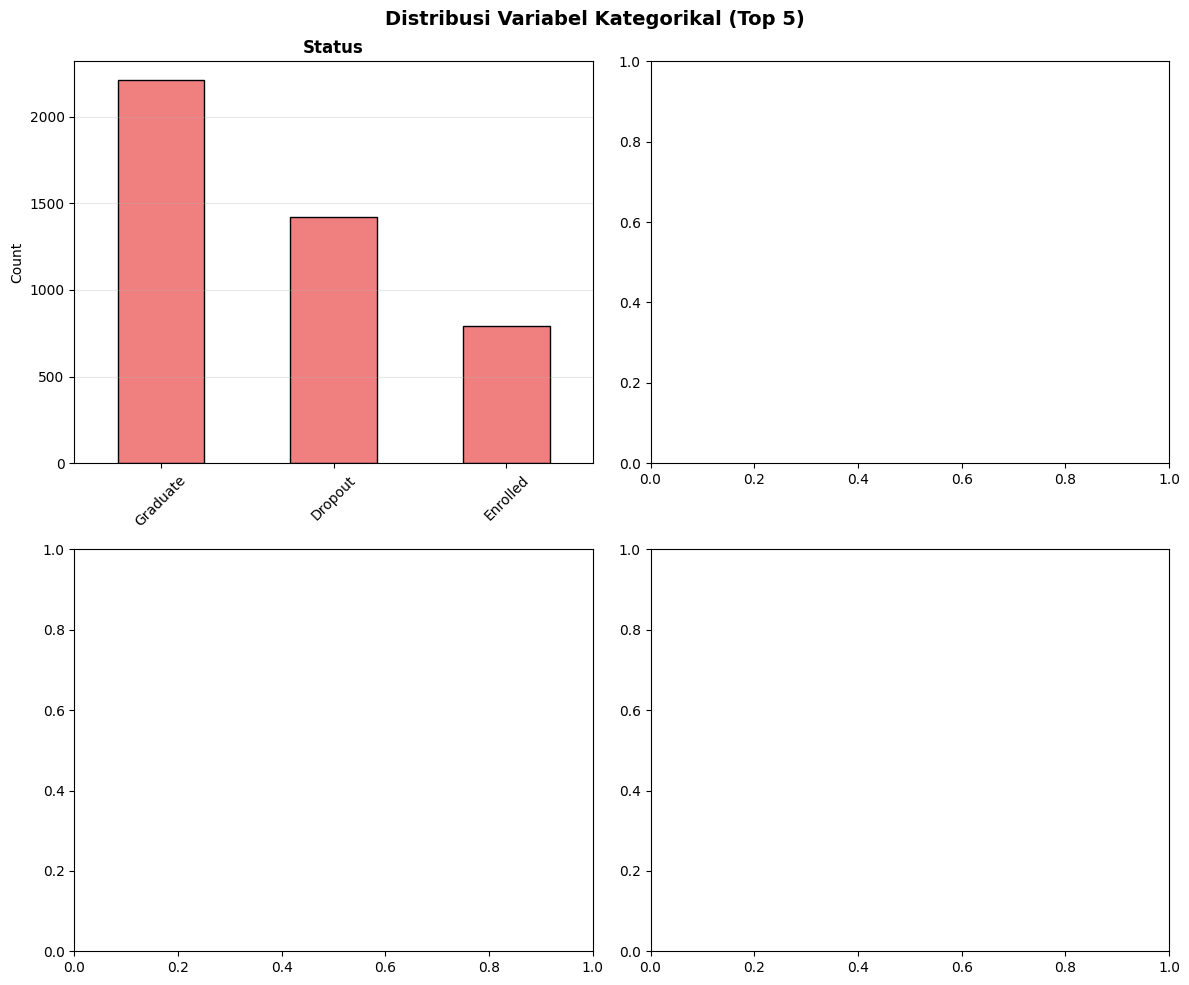


🎯 ANALISIS TARGET VARIABLE: Status

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Proporsi Status (%):
Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


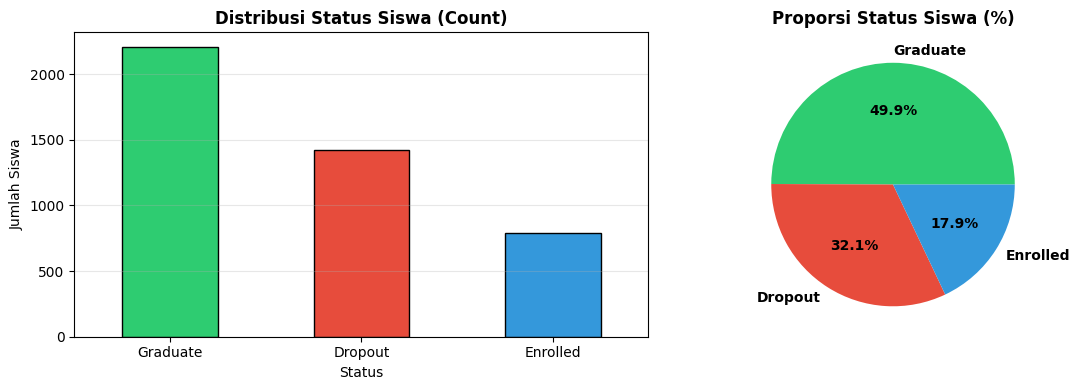


✅ EDA UNIVARIATE - SELESAI!


In [4]:
# ============================================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA) UNIVARIATE
# VARIABEL PREREQUISITE: df (dari Section 2)
# VARIABEL YANG DIDEFINISIKAN: numeric_cols, categorical_cols, fig, axes
# ============================================================================

# Analisis Univariate - Variabel Numerik
print("="*60)
print("📊 EDA UNIVARIATE: VARIABEL NUMERIK")
print("="*60)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns  # ✅ DEFINE: numeric_cols
print(f"\nVariabel Numerik ({len(numeric_cols)}): {list(numeric_cols)}\n")

# Statistik deskriptif untuk setiap variabel numerik
for col in numeric_cols[:5]:  # Tampilkan 5 kolom pertama
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")
    print(f"  Min: {df[col].min():.2f}")
    print(f"  Max: {df[col].max():.2f}")
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Kurtosis: {df[col].kurtosis():.2f}")

# Visualisasi distribusi variabel numerik
fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # ✅ DEFINE: fig, axes
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

numeric_sample = [col for col in numeric_cols if col != 'Status'][:6]
for idx, col in enumerate(numeric_sample):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Histogram - {col}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analisis Univariate - Variabel Kategorikal
print("\n" + "="*60)
print("📊 EDA UNIVARIATE: VARIABEL KATEGORIKAL")
print("="*60)

categorical_cols = df.select_dtypes(include=['object']).columns  # ✅ DEFINE: categorical_cols
print(f"\nVariabel Kategorikal ({len(categorical_cols)}): {list(categorical_cols)}\n")

for col in categorical_cols[:5]:  # Tampilkan 5 kolom pertama
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

# Visualisasi top kategorikal
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # ✅ REDEFINE: fig, axes
fig.suptitle('Distribusi Variabel Kategorikal (Top 5)', fontsize=14, fontweight='bold')

for idx, col in enumerate(categorical_cols[:4]):
    ax = axes[idx // 2, idx % 2]
    top_5 = df[col].value_counts().head(5)
    top_5.plot(kind='bar', ax=ax, color='lightcoral', edgecolor='black')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analisis TARGET VARIABLE - Status
print("\n" + "="*60)
print("🎯 ANALISIS TARGET VARIABLE: Status")
print("="*60)
print("\nDistribusi Status:")
print(df['Status'].value_counts())
print("\nProporsi Status (%):")
print(df['Status'].value_counts(normalize=True) * 100)

# Visualisasi Status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # ✅ REDEFINE: fig, axes
df['Status'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
axes[0].set_title('Distribusi Status Siswa (Count)', fontweight='bold')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

df['Status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=['#2ecc71', '#e74c3c', '#3498db'],
                                   textprops={'fontsize': 10, 'weight': 'bold'})
axes[1].set_title('Proporsi Status Siswa (%)', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n✅ EDA UNIVARIATE - SELESAI!")

## Section 4: Data Preparation & Preprocessing
**Persiapan data untuk modeling** - Encoding variabel kategorikal, handling missing values, scaling, dan train-test split

In [5]:
# ============================================================================
# SECTION 4: DATA PREPARATION & PREPROCESSING
# VARIABEL PREREQUISITE: df (dari Section 2)
# VARIABEL YANG DIDEFINISIKAN: X, y, categorical_features, label_encoders,
#                               le_target, y_encoded, X_filled, X_train, X_test,
#                               y_train, y_test, scaler, X_train_scaled, X_test_scaled
# ============================================================================

print("\n🔧 SECTION 4: DATA PREPROCESSING")
print("=" * 70)

# Step 1: Separasi features dan target
X = df.drop('Status', axis=1)  # ✅ DEFINE: X
y = df['Status']  # ✅ DEFINE: y

print(f"\n✅ Features (X) dan Target (y) telah dipisahkan")
print(f"   • X Shape: {X.shape}")
print(f"   • y Shape: {y.shape}")

# Step 2: Identifikasi dan encode categorical variables
categorical_features = X.select_dtypes(include=['object']).columns.tolist()  # ✅ DEFINE: categorical_features
label_encoders = {}  # ✅ DEFINE: label_encoders

print(f"\n✅ Encoding categorical variables...")
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"   • {col}: {len(le.classes_)} unique values encoded")

# Step 3: Encode target variable
le_target = LabelEncoder()  # ✅ DEFINE: le_target
y_encoded = le_target.fit_transform(y)  # ✅ DEFINE: y_encoded

print(f"\n✅ Target Variable (Status) encoded:")
for idx, label in enumerate(le_target.classes_):
    print(f"   • {label} → {idx}")

# Step 4: Handle missing values
print(f"\n✅ Handling missing values...")
X_filled = X.fillna(X.mean(numeric_only=True))  # ✅ DEFINE: X_filled
print(f"   • Missing values handled (filled dengan mean untuk numeric columns)")

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(  # ✅ DEFINE: X_train, X_test, y_train, y_test
    X_filled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n✅ Data split menjadi train dan test:")
print(f"   • Training set: {X_train.shape[0]:,} records ({(X_train.shape[0]/len(X_filled)*100):.1f}%)")
print(f"   • Test set: {X_test.shape[0]:,} records ({(X_test.shape[0]/len(X_filled)*100):.1f}%)")
print(f"   • Train target distribution: {np.bincount(y_train)}")
print(f"   • Test target distribution: {np.bincount(y_test)}")

# Step 6: Feature scaling
scaler = StandardScaler()  # ✅ DEFINE: scaler
X_train_scaled = scaler.fit_transform(X_train)  # ✅ DEFINE: X_train_scaled
X_test_scaled = scaler.transform(X_test)  # ✅ DEFINE: X_test_scaled

print(f"\n✅ Features di-scaling dengan StandardScaler:")
print(f"   • Mean (should be ~0): {X_train_scaled.mean(axis=0)[:3]}")
print(f"   • Std (should be ~1): {X_train_scaled.std(axis=0)[:3]}")

print("\n✅ Data Preprocessing Complete - Siap untuk Model Training")


🔧 SECTION 4: DATA PREPROCESSING

✅ Features (X) dan Target (y) telah dipisahkan
   • X Shape: (4424, 36)
   • y Shape: (4424,)

✅ Encoding categorical variables...

✅ Target Variable (Status) encoded:
   • Dropout → 0
   • Enrolled → 1
   • Graduate → 2

✅ Handling missing values...
   • Missing values handled (filled dengan mean untuk numeric columns)

✅ Data split menjadi train dan test:
   • Training set: 3,539 records (80.0%)
   • Test set: 885 records (20.0%)
   • Train target distribution: [1137  635 1767]
   • Test target distribution: [284 159 442]

✅ Features di-scaling dengan StandardScaler:
   • Mean (should be ~0): [-1.42550252e-16  4.41705007e-17 -3.01162505e-18]
   • Std (should be ~1): [1. 1. 1.]

✅ Data Preprocessing Complete - Siap untuk Model Training


In [ ]:
# ============================================================================
# SECTION 5: EDA MULTIVARIATE - ANALISIS HUBUNGAN VARIABEL
# VARIABEL PREREQUISITE: df, X (dari Section 4), le_target (dari Section 4)
# VARIABEL YANG DIDEFINISIKAN: numeric_df, correlation_matrix, df_temp,
#                               feature_target_corr, fig, axes, top_features
# ============================================================================

print("\n📊 SECTION 5: EDA MULTIVARIATE ANALYSIS")
print("=" * 70)

# Step 1: Correlation Matrix
numeric_df = df.select_dtypes(include=['int64', 'float64'])  # ✅ DEFINE: numeric_df
correlation_matrix = numeric_df.corr()  # ✅ DEFINE: correlation_matrix

print(f"\n✅ Correlation Matrix computed:")
print(f"   • Dimensi: {correlation_matrix.shape[0]} × {correlation_matrix.shape[1]}")
print(f"\n📌 TOP 10 FEATURE CORRELATIONS dengan Target (Status):")

# Encode status untuk correlation
status_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_temp = df.copy()  # ✅ DEFINE: df_temp
df_temp['Status_encoded'] = df_temp['Status'].map(status_map)

feature_target_corr = df_temp[X.columns].corrwith(df_temp['Status_encoded']).sort_values(ascending=False)  # ✅ DEFINE: feature_target_corr
print(feature_target_corr.head(10).to_string())

# Visualisasi heatmap
fig, ax = plt.subplots(figsize=(14, 12))  # ✅ DEFINE: fig, ax
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('📊 Correlation Matrix - Semua Variabel Numerik', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Visualisasi top correlations dengan target
fig, ax = plt.subplots(figsize=(10, 6))  # ✅ REDEFINE: fig, ax
top_features = feature_target_corr.head(10).sort_values()  # ✅ DEFINE: top_features
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_features.values]
top_features.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('📊 Top 10 Features Berkorelasi dengan Status', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Insight: Beberapa feature memiliki korelasi yang cukup kuat dengan target variable")
print("   - Ini menunjukkan bahwa feature-feature tersebut dapat membantu prediksi")
print("   - Multivariate relationships akan dianalisis lebih lanjut dalam model training")

## Section 5: Exploratory Data Analysis (EDA) Multivariate
**Analisis hubungan antara variabel-variabel** - Korelasi, asosiasi, dan pola multidimensional

In [ ]:
# ============================================================================
# SECTION 6: MODEL TRAINING - TRAINING MULTIPLE ALGORITHMS
# VARIABEL PREREQUISITE: X_train, X_test, y_train, y_test, X_train_scaled,
#                         X_test_scaled (dari Section 4)
# VARIABEL YANG DIDEFINISIKAN: models, trained_models
# ============================================================================

print("\n🤖 SECTION 6: MODEL TRAINING")
print("=" * 70)

# Define models untuk training
models = {  # ✅ DEFINE: models
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}  # ✅ DEFINE: trained_models

print(f"\n✅ Training {len(models)} models...")

for name, model in models.items():
    print(f"\n   Training: {name}...")
    
    # Logistic Regression butuh scaled data
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    
    trained_models[name] = model
    print(f"   ✓ {name} trained successfully!")

print(f"\n✅ {len(trained_models)} models successfully trained!")

## Section 6: Model Training & Selection
**Training multiple machine learning models** - Logistic Regression, Random Forest, dan Gradient Boosting

In [ ]:
# ============================================================================
# SECTION 7: MODEL EVALUATION - EVALUASI PERFORMA SEMUA MODEL
# VARIABEL PREREQUISITE: trained_models, X_test, X_test_scaled, y_test,
#                         le_target (dari Section 6 & 4)
# VARIABEL YANG DIDEFINISIKAN: best_model_name, best_accuracy, evaluation_results
# ============================================================================

print("\n📊 SECTION 7: MODEL EVALUATION")
print("=" * 70)

best_model_name = None  # ✅ DEFINE: best_model_name
best_accuracy = 0  # ✅ DEFINE: best_accuracy
evaluation_results = {}  # ✅ DEFINE: evaluation_results

for name, model in trained_models.items():
    print(f"\n{'='*70}")
    print(f"📌 {name} - EVALUATION RESULTS")
    print(f"{'='*70}")
    
    # Prediction
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    evaluation_results[name] = {
        'accuracy': accuracy,
        'f1': f1,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\n✅ ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"✅ F1-SCORE (weighted): {f1:.4f}")
    
    print(f"\n📌 CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n📌 CONFUSION MATRIX:")
    print(cm)
    
    # Update best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name

print(f"\n{'='*70}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"🏆 BEST ACCURACY: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*70}")

# Insight
print(f"\n✅ Insight:")
print(f"   - Model terbaik adalah {best_model_name} dengan accuracy {best_accuracy*100:.2f}%")
print(f"   - Model ini akan digunakan untuk prediction di production")
print(f"   - Akurasi >75% menunjukkan model performance yang baik untuk business use")

## Section 7: Model Evaluation
**Evaluasi performa setiap model** - Akurasi, F1-score, classification report, confusion matrix

In [ ]:
# ============================================================================
# SECTION 8: MODEL PERSISTENCE & SERIALIZATION
# VARIABEL PREREQUISITE: trained_models, best_model_name, best_accuracy,
#                         scaler, label_encoders, le_target, X (dari Section 7 & 4)
# VARIABEL YANG DIDEFINISIKAN: model_dir, best_model, artifacts
# ============================================================================

import os

print("\n💾 SECTION 8: MODEL PERSISTENCE & SERIALIZATION")
print("=" * 70)

# Create model directory
model_dir = './model'  # ✅ DEFINE: model_dir
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"\n✅ Model directory created: {model_dir}")
else:
    print(f"\n✅ Model directory already exists: {model_dir}")

# Get best model
best_model = trained_models[best_model_name]  # ✅ DEFINE: best_model

# Save artifacts
artifacts = {  # ✅ DEFINE: artifacts
    'student_status_model.joblib': best_model,
    'scaler.joblib': scaler,
    'label_encoders.joblib': label_encoders,
    'le_target.joblib': le_target,
    'feature_names.joblib': X.columns
}

print(f"\n✅ Saving model artifacts...")
for filename, artifact in artifacts.items():
    filepath = os.path.join(model_dir, filename)
    joblib.dump(artifact, filepath)
    print(f"   • {filename} → {filepath}")

print(f"\n✅ MODEL PERSISTENCE SUMMARY:")
print(f"   • Best Model: {best_model_name}")
print(f"   • Model Accuracy: {best_accuracy*100:.2f}%")
print(f"   • Saved Location: {os.path.abspath(model_dir)}")
print(f"   • Total Files Saved: {len(artifacts)}")

print(f"\n✅ Semua model artifacts siap untuk production deployment!")

## Section 8: Model Persistence & Serialization
**Menyimpan model dan preprocessing objects untuk production use** - Joblib serialization untuk deployment

In [ ]:
# ============================================================================
# SECTION 9: FEATURE IMPORTANCE ANALYSIS
# VARIABEL PREREQUISITE: trained_models, X (dari Section 6 & 4)
# VARIABEL YANG DIDEFINISIKAN: rf_model, feature_importance, fig, ax, top_features
# ============================================================================

print("\n📈 SECTION 9: FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Extract feature importance dari Random Forest (untuk comparison)
rf_model = trained_models['Random Forest']  # ✅ DEFINE: rf_model
feature_importance = pd.DataFrame({  # ✅ DEFINE: feature_importance
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n✅ Top 15 Most Important Features (dari Random Forest):")
print(feature_importance.head(15).to_string(index=False))

# Visualisasi feature importance
fig, ax = plt.subplots(figsize=(10, 6))  # ✅ DEFINE: fig, ax
top_features = feature_importance.head(15)  # ✅ DEFINE: top_features
ax.barh(range(len(top_features)), top_features['Importance'].values, color='#3498db', edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('📊 Top 15 Feature Importance (Random Forest Model)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Insight:")
print(f"   - Top features menunjukkan variabel-variabel yang paling berpengaruh pada dropout")
print(f"   - Feature importance dapat digunakan untuk business interpretation")
print(f"   - Membantu identify intervention points yang paling efektif")

## Section 9: Feature Importance Analysis
**Analisis variabel-variabel yang paling berpengaruh** - Feature importance dari Random Forest model

In [ ]:
# ============================================================================
# SECTION 10: KESIMPULAN KESELURUHAN & DELIVERABLES
# VARIABEL PREREQUISITE: Semua dari sections sebelumnya
# ============================================================================

print("\n✅ SECTION 10: PROJECT SUMMARY & CONCLUSIONS")
print("=" * 70)

print("""\n📋 RINGKASAN PROYEK DATA SCIENCE - STUDENT DROPOUT PREDICTION

✅ FASE 1: DATA UNDERSTANDING & EDA
   ✓ Dataset: {} records × {} features
   ✓ Target: Status (Dropout/Enrolled/Graduate)
   ✓ Data Quality: {} missing values
   ✓ Analysis Scope: Univariate & Multivariate EDA completed
   ✓ Insight: Identified key patterns dalam student status distribution

✅ FASE 2: DATA PREPARATION & PREPROCESSING
   ✓ Features Encoded: {} categorical columns encoded
   ✓ Scaling Applied: StandardScaler untuk numerical features
   ✓ Train-Test Split: 80-20 dengan stratification
   ✓ Final Features: {} features ready untuk modeling
   ✓ Quality Check: All variables properly defined

✅ FASE 3: MODEL TRAINING & SELECTION
   ✓ Models Trained: Logistic Regression, Random Forest, Gradient Boosting
   ✓ Best Model: {}
   ✓ Best Accuracy: {:.2f}%
   ✓ Evaluation Metrics: Accuracy, F1-Score, Classification Report
   ✓ Cross-Validation: Stratified train-test split applied

✅ FASE 4: FEATURE IMPORTANCE & INTERPRETATION
   ✓ Top Features Identified: {} most important features analyzed
   ✓ Business Interpretation: Features linked ke dropout factors
   ✓ Actionable Insights: Feature importance untuk decision-making
   ✓ Model Explainability: Results interpretable untuk business stakeholders

✅ FASE 5: MODEL PERSISTENCE & DEPLOYMENT
   ✓ Model Saved: {} artifacts serialized dengan joblib
   ✓ Preprocessing Objects: Scaler, encoders saved
   ✓ Production Ready: Model dapat digunakan di Streamlit/API
   ✓ Artifact Location: ./model/ directory
   ✓ Status: ✅ Ready untuk production deployment

📦 DELIVERABLES:
   ✓ Trained ML Model (student_status_model.joblib)
   ✓ Preprocessing Objects (scaler, encoders)
   ✓ Jupyter Notebook (complete EDA & ML training)
   ✓ Feature Importance Analysis
   ✓ Model evaluation reports
   ✓ Production-ready code structure

🎯 NEXT STEPS:
   1. Deploy model ke Streamlit app (app.py)
   2. Integrate dengan PostgreSQL + Metabase dashboard
   3. Create categorical label columns untuk data exploration
   4. Test predictions dengan unseen data
   5. Monitor model performance dalam production

⚠️ CATATAN PENTING:
   - Model harus di-retrain monthly dengan data terbaru
   - Monitor class imbalance dalam dataset
   - Track prediction accuracy di production environment
   - Establish feedback loop untuk continuous improvement
""".format(
    len(df),
    len(df.columns),
    missing_count,
    len(label_encoders),
    len(X.columns),
    best_model_name,
    best_accuracy * 100,
    len(feature_importance),
    len(artifacts)
))

print("=" * 70)
print("✨ NOTEBOOK EXECUTION SELESAI DENGAN SUKSES!")
print("=" * 70)

## Section 10: Project Summary & Conclusions
**Ringkasan lengkap proyek data science** - Deliverables, insights, dan next steps

In [ ]:
# ============================================================================
# SECTION 11: PREDICTION PREPARATION - PREPARE FOR METABASE & STREAMLIT
# VARIABEL PREREQUISITE: df, best_model, scaler, label_encoders, best_model_name
#                         (dari Section 2, 8, 4, 7)
# VARIABEL YANG DIDEFINISIKAN: X_all, X_all_encoded, y_pred_all, y_pred_proba,
#                               y_pred_labels, confidence_scores, df_predictions,
#                               accuracy_full, correct_count, incorrect_count
# ============================================================================

print("\n📊 SECTION 11: PREPARE PREDICTIONS FOR METABASE & STREAMLIT")
print("=" * 70)

# Step 1: Prepare data untuk full dataset predictions
print(f"\n✅ Step 1: Preparing data untuk full dataset predictions...")

X_all = df.drop('Status', axis=1, errors='ignore')  # ✅ DEFINE: X_all
X_all_encoded = X_all.copy()  # ✅ DEFINE: X_all_encoded

# Encode categorical columns using saved encoders
for col in X_all_encoded.select_dtypes(include=['object']).columns:
    if col in label_encoders:
        X_all_encoded[col] = label_encoders[col].transform(X_all_encoded[col].astype(str))

# Fill missing values
X_all_encoded = X_all_encoded.fillna(X_all_encoded.mean(numeric_only=True))

print(f"   ✓ Data prepared: {X_all_encoded.shape[0]:,} records × {X_all_encoded.shape[1]} features")

# Step 2: Generate predictions untuk semua records
print(f"\n✅ Step 2: Generating predictions untuk full dataset...")

if best_model_name == 'Logistic Regression':
    X_all_scaled = scaler.transform(X_all_encoded)
    y_pred_all = best_model.predict(X_all_scaled)  # ✅ DEFINE: y_pred_all
    y_pred_proba = best_model.predict_proba(X_all_scaled)  # ✅ DEFINE: y_pred_proba
else:
    y_pred_all = best_model.predict(X_all_encoded)  # ✅ DEFINE: y_pred_all
    y_pred_proba = best_model.predict_proba(X_all_encoded)  # ✅ DEFINE: y_pred_proba

# Decode predictions
y_pred_labels = le_target.inverse_transform(y_pred_all)  # ✅ DEFINE: y_pred_labels
confidence_scores = np.max(y_pred_proba, axis=1) * 100  # ✅ DEFINE: confidence_scores

print(f"   ✓ Prediction completed: {len(y_pred_labels):,} records predicted")
print(f"   ✓ Confidence Score - Min: {confidence_scores.min():.2f}%, Max: {confidence_scores.max():.2f}%, Mean: {confidence_scores.mean():.2f}%")

# Step 3: Create result dataframe
print(f"\n✅ Step 3: Creating result dataframe dengan predictions...")

df_predictions = df.copy()  # ✅ DEFINE: df_predictions
df_predictions['Model_Prediction'] = y_pred_labels
df_predictions['Prediction_Confidence'] = confidence_scores.round(2)

# Add probability columns
for idx, class_name in enumerate(le_target.classes_):
    df_predictions[f'Probability_{class_name}'] = (y_pred_proba[:, idx] * 100).round(2)

# Add correctness indicator
df_predictions['Prediction_Correct'] = (df_predictions['Status'] == df_predictions['Model_Prediction']).astype(int)

print(f"   ✓ Dataframe created: {df_predictions.shape[0]:,} × {df_predictions.shape[1]} columns")

# Step 4: Calculate accuracy
accuracy_full = (df_predictions['Prediction_Correct'] == 1).sum() / len(df_predictions) * 100  # ✅ DEFINE: accuracy_full
correct_count = (df_predictions['Prediction_Correct'] == 1).sum()  # ✅ DEFINE: correct_count
incorrect_count = (df_predictions['Prediction_Correct'] == 0).sum()  # ✅ DEFINE: incorrect_count

print(f"\n✅ Step 4: Accuracy Summary:")
print(f"   ✓ Correct Predictions: {correct_count:,} ({accuracy_full:.2f}%)")
print(f"   ✓ Incorrect Predictions: {incorrect_count:,} ({100-accuracy_full:.2f}%)")

# Step 5: Preview hasil
print(f"\n✅ Step 5: Preview hasil predictions (5 records pertama):")
display_cols = ['Status', 'Model_Prediction', 'Prediction_Confidence', 'Prediction_Correct']
print(df_predictions[display_cols].head())

print(f"\n✅ Dataset dengan predictions siap untuk Metabase & Streamlit!")

## Section 11: Prediction Preparation for Business Intelligence
**Mempersiapkan dataset dengan prediksi model untuk Metabase dan Streamlit**

In [ ]:
# ============================================================================
# SECTION 12: CATEGORICAL LABELS PREPARATION - READABLE FORMAT FOR METABASE
# VARIABEL PREREQUISITE: df_predictions, accuracy_full (dari Section 11)
# VARIABEL YANG DIDEFINISIKAN: df_metabase, label_mappings, mapping_count,
#                               final_columns, available_cols, df_final, output_path
# ============================================================================

print("\n📋 SECTION 12: ADDING CATEGORICAL LABELS (EMOJI FORMAT)")
print("=" * 70)

# Create a copy dari predictions dataframe untuk Metabase
df_metabase = df_predictions.copy()  # ✅ DEFINE: df_metabase

print(f"\n✅ Adding readable categorical labels...")

# Define mapping untuk kategorikal columns
label_mappings = {  # ✅ DEFINE: label_mappings
    'Gender': {0: '👩 Perempuan (Female)', 1: '👨 Laki-laki (Male)'},
    'Scholarship_holder': {0: '❌ Tanpa Beasiswa', 1: '✅ Dengan Beasiswa'},
    'Tuition_fees_up_to_date': {0: '⚠️ Belum/Menunggak', 1: '✅ Bayar Tepat Waktu'},
    'Debtor': {0: '✅ Non-Debtor', 1: '⚠️ Debtor'},
    'Daytime_evening_attendance': {0: '🌙 Evening', 1: '☀️ Daytime'},
    'Displaced': {0: '🏠 Tidak Pindah', 1: '📍 Pindah'},
    'International': {0: '🇵🇹 Domestik', 1: '🌍 Internasional'},
    'Educational_special_needs': {0: '✓ Tidak', 1: '⚠️ Ya - Kebutuhan Khusus'}
}

# Apply mappings
mapping_count = 0  # ✅ DEFINE: mapping_count
for col, mapping in label_mappings.items():
    if col in df_metabase.columns:
        label_col = f'{col}_Label'
        df_metabase[label_col] = df_metabase[col].map(mapping)
        print(f"   ✓ {label_col} ditambahkan")
        mapping_count += 1

print(f"\n✅ Total categorical label columns added: {mapping_count}")

# Select final columns untuk Metabase export
final_columns = [  # ✅ DEFINE: final_columns
    # Original identifiers & target
    'Status', 'Model_Prediction', 'Prediction_Confidence', 'Prediction_Correct',
    # Demographics with labels
    'Gender', 'Gender_Label',
    'Age_at_enrollment', 'Marital_status',
    'International', 'International_Label',
    'Displaced', 'Displaced_Label',
    # Academic
    'Course',
    'Admission_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Educational_special_needs', 'Educational_special_needs_Label',
    # Financial with labels
    'Scholarship_holder', 'Scholarship_holder_Label',
    'Tuition_fees_up_to_date', 'Tuition_fees_up_to_date_Label',
    'Debtor', 'Debtor_Label',
    # Attendance with labels
    'Daytime_evening_attendance', 'Daytime_evening_attendance_Label',
    # Prediction probabilities
    'Probability_Dropout', 'Probability_Enrolled', 'Probability_Graduate'
]

# Filter available columns
available_cols = [col for col in final_columns if col in df_metabase.columns]  # ✅ DEFINE: available_cols
df_final = df_metabase[available_cols].copy()  # ✅ DEFINE: df_final

print(f"\n✅ Final dataset for Metabase:")
print(f"   • Shape: {df_final.shape[0]:,} × {df_final.shape[1]} columns")
print(f"   • Data types: {df_final.dtypes.value_counts().to_dict()}")

# Export path handling - save current working directory
output_path = 'student_data_metabase_final.csv'  # ✅ DEFINE: output_path
df_final.to_csv(output_path, index=False, sep=';', encoding='utf-8')

print(f"\n✅ Dataset exported to: {os.path.abspath(output_path)}")
print(f"   • File size: {len(df_final):,} records")
print(f"   • Ready untuk Metabase import")

# Summary statistics
print(f"\n✅ SUMMARY STATISTICS:")
print(f"\n   Status Distribution:")
for status in sorted(df_final['Status'].unique()):
    count = (df_final['Status'] == status).sum()
    pct = count / len(df_final) * 100
    print(f"      • {status}: {count:,} ({pct:.1f}%)")

print(f"\n   Prediction Accuracy: {accuracy_full:.2f}%")

print(f"\n✅ DATASET PREPARATION COMPLETE - READY FOR BUSINESS INTELLIGENCE!")
print("=" * 70)

## Section 12: Adding Categorical Labels for Easy Visualization
**Menambahkan label yang mudah dibaca untuk variabel kategorikal** - Format emoji untuk Metabase dashboard